In [1]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ddonz\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
pasta_diretorio = r'\ABAW\data'

In [3]:
os.listdir(pasta_diretorio)

['bah-video.csv',
 'BAH_dataset_documentation.pdf',
 'BAH_Dataset_EULA-2.pdf',
 'cropped-aligned-faces',
 'extract_frames_from_videos.py',
 'extract_frames_from_videos.sh',
 'Frames',
 'meta_data.yml',
 'readme.md',
 'split',
 'split-frames',
 'transcription',
 'version.txt',
 'Videos',
 'video_annotation_transcript.yaml']

In [4]:
df = pd.read_csv(os.path.join(pasta_diretorio, 'bah-video.csv'))

In [5]:
df.head()

,video-path,label
0,Videos/82694/Visite_1/82694_Question_1_2024-11...,0
1,Videos/82694/Visite_1/82694_Question_2_2024-11...,1
2,Videos/82694/Visite_1/82694_Question_3_2024-11...,1
3,Videos/82694/Visite_1/82694_Question_4_2024-11...,1
4,Videos/82694/Visite_1/82694_Question_5_2024-11...,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1427 entries, 0 to 1426
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   video-path  1427 non-null   str  
 1   label       1427 non-null   int64
dtypes: int64(1), str(1)
memory usage: 22.4 KB


In [7]:
df["label"].value_counts()

label
1    778
0    649
Name: count, dtype: int64

In [8]:
df["participant_id"] = df["video-path"].str.split("/").str[1]

df.head()

,video-path,label,participant_id
0,Videos/82694/Visite_1/82694_Question_1_2024-11...,0,82694
1,Videos/82694/Visite_1/82694_Question_2_2024-11...,1,82694
2,Videos/82694/Visite_1/82694_Question_3_2024-11...,1,82694
3,Videos/82694/Visite_1/82694_Question_4_2024-11...,1,82694
4,Videos/82694/Visite_1/82694_Question_5_2024-11...,1,82694


In [9]:
df["participant_id"].dtype

dtype('O')

In [10]:
df["participant_id"] = df["participant_id"].astype(int)

In [11]:
excluded_ids = [
82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
83045, 83080, 83086
]

In [12]:
df_filtered = df[~df["participant_id"].isin(excluded_ids)]

In [13]:
df_filtered["label"].value_counts()

label
1    618
0    514
Name: count, dtype: int64

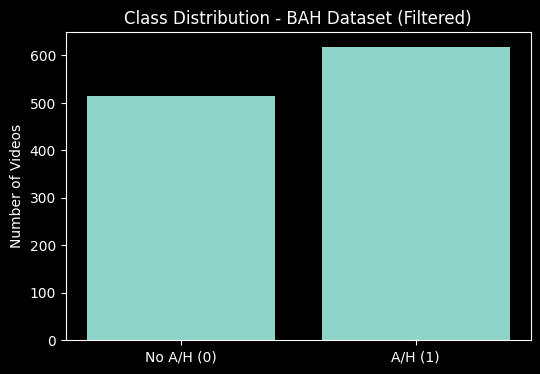

In [14]:
counts = df_filtered["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

plt.xticks([0,1], ["No A/H (0)", "A/H (1)"])
plt.ylabel("Number of Videos")
plt.title("Class Distribution - BAH Dataset (Filtered)")

plt.show()

# Distribuição por participante

Vídeos por participante:
  Min: 1
  Max: 7
  Média: 4.7
  Total participantes: 239


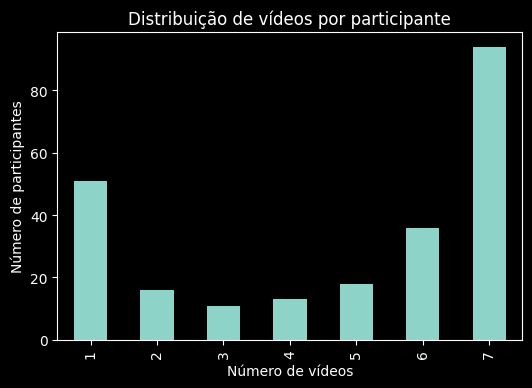

In [16]:
videos_per_participant = df_filtered.groupby("participant_id").size()
print(f"Vídeos por participante:")
print(f"  Min: {videos_per_participant.min()}")
print(f"  Max: {videos_per_participant.max()}")
print(f"  Média: {videos_per_participant.mean():.1f}")
print(f"  Total participantes: {len(videos_per_participant)}")
plt.figure(figsize=(6,4))
videos_per_participant.value_counts().sort_index().plot(kind='bar')
plt.xlabel("Número de vídeos")
plt.ylabel("Número de participantes")
plt.title("Distribuição de vídeos por participante")
plt.show()

Sempre A/H (100% dos vídeos): 27 participantes
Nunca A/H (0% dos vídeos): 44 participantes
Misto: 168 participantes


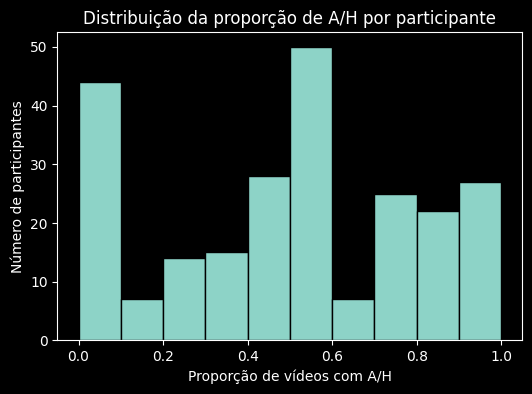

In [17]:
# Proporção de A/H por participante
ah_ratio = df_filtered.groupby("participant_id")["label"].mean()

# Participantes que são sempre A/H ou nunca A/H
sempre_ah = (ah_ratio == 1.0).sum()
nunca_ah = (ah_ratio == 0.0).sum()
misto = ((ah_ratio > 0.0) & (ah_ratio < 1.0)).sum()

print(f"Sempre A/H (100% dos vídeos): {sempre_ah} participantes")
print(f"Nunca A/H (0% dos vídeos): {nunca_ah} participantes")
print(f"Misto: {misto} participantes")

# Distribuição da proporção
plt.figure(figsize=(6,4))
plt.hist(ah_ratio, bins=10, edgecolor='black')
plt.xlabel("Proporção de vídeos com A/H")
plt.ylabel("Número de participantes")
plt.title("Distribuição da proporção de A/H por participante")
plt.show()

# Splits train/val/test

In [18]:
# Ler os splits
split_dir = os.path.join(pasta_diretorio, 'split')
print("Arquivos em split:", os.listdir(split_dir))

Arquivos em split: ['class_id.yaml', 'test.txt', 'train.txt', 'val.txt']


In [19]:
# Ler cada split
splits = {}
for filename in os.listdir(split_dir):
    filepath = os.path.join(split_dir, filename)
    split_name = filename.replace('.csv', '').replace('.txt', '')
    # tentar ler pra ver o formato
    with open(filepath, 'r') as f:
        lines = f.readlines()
    print(f"\n--- {filename} ---")
    print(f"Total linhas: {len(lines)}")
    print(f"Primeiras 3 linhas:")
    for line in lines[:3]:
        print(f"  {line.strip()}")


--- class_id.yaml ---
Total linhas: 2
Primeiras 3 linhas:
  With A-H: 1
  No A-H: 0

--- test.txt ---
Total linhas: 525
Primeiras 3 linhas:
  Videos/82578/Visite_1/82578_Question_1_2024-10-02_16-03-17_Video.mp4,0,when I wake up usually I check my mobile phone and I just see if there is anything left after that I just go to washroom brush my teeth and just get ready for my day for the day
  Videos/82578/Visite_1/82578_Question_2_2024-10-02_16-04-10_Video.mp4,1,when I make a lot of money I feel joy that's the straight answer
  Videos/82578/Visite_1/82578_Question_3_2024-10-02_16-04-27_Video.mp4,0,I really don't like to waste my time browsing like social medias they're just horrible

--- train.txt ---
Total linhas: 778
Primeiras 3 linhas:
  Videos/82782/Visite_1/82782_Question_2_2024-12-09_17-16-53_Video.mp4,0,My hobby is traveling. I like to visit different places, different countries, different tourist attractions. Even though it costs a lot of money, I prefer traveling over or spendin

In [20]:
# Analisar distribuição de classes por split
for split_name in ['train', 'val', 'test']:
    filepath = os.path.join(split_dir, f'{split_name}.txt')
    labels = []
    with open(filepath, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split(',')
            labels.append(int(parts[1]))

    total = len(labels)
    ah = sum(labels)
    no_ah = total - ah
    print(f"{split_name}: {total} vídeos | A/H: {ah} ({ah/total*100:.1f}%) | No A/H: {no_ah} ({no_ah/total*100:.1f}%)")

train: 778 vídeos | A/H: 385 (49.5%) | No A/H: 393 (50.5%)
val: 124 vídeos | A/H: 75 (60.5%) | No A/H: 49 (39.5%)
test: 525 vídeos | A/H: 318 (60.6%) | No A/H: 207 (39.4%)


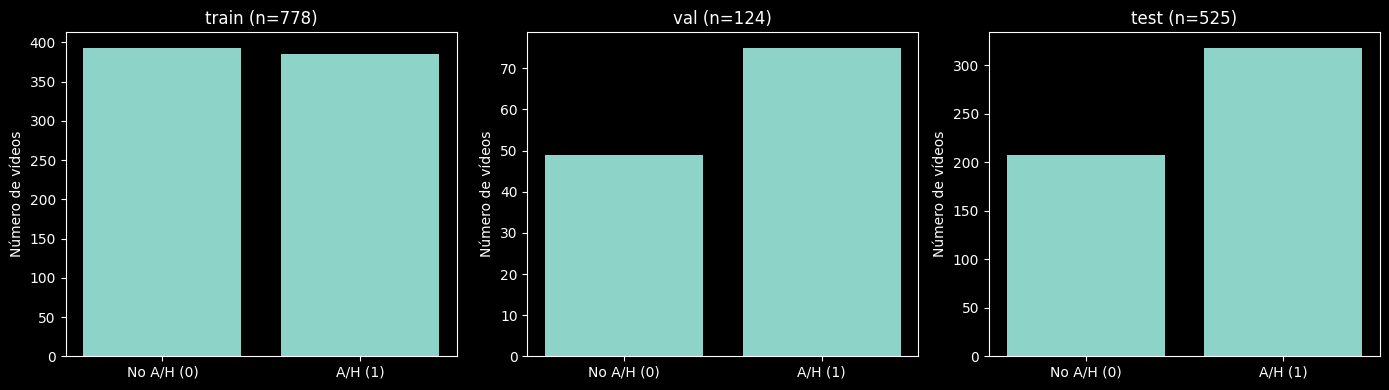

In [21]:
# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, split_name in enumerate(['train', 'val', 'test']):
    filepath = os.path.join(split_dir, f'{split_name}.txt')
    labels = []
    with open(filepath, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split(',')
            labels.append(int(parts[1]))

    counts = pd.Series(labels).value_counts().sort_index()
    axes[i].bar(counts.index, counts.values)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No A/H (0)", "A/H (1)"])
    axes[i].set_title(f"{split_name} (n={len(labels)})")
    axes[i].set_ylabel("Número de vídeos")

plt.tight_layout()
plt.show()

# Analise anotações frame-level

In [23]:
import yaml

yaml_path = os.path.join(pasta_diretorio, 'video_annotation_transcript.yaml')
with open(yaml_path, 'r', encoding='utf-8') as f:
    annotations = yaml.full_load(f)

# Ver estrutura geral
print(f"Total de vídeos anotados: {len(annotations)}")
print(f"\nChaves disponíveis por vídeo:")
first_key = list(annotations.keys())[0]
print(f"  Video ID: {first_key}")
print(f"  Campos: {list(annotations[first_key].keys())}")

Total de vídeos anotados: 1427

Chaves disponíveis por vídeo:
  Video ID: Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4
  Campos: ['all_cues', 'annotator_id', 'certainty_ah', 'fr_detailed_ah', 'frame_annotation', 'global_ah', 'time_detailed_ah', 'transcript']


In [24]:
# Explorar um vídeo de exemplo em detalhe
video = annotations[first_key]

print(f"=== Vídeo: {first_key} ===\n")

print(f"Label global (global_ah): {video.get('global_ah')}")
print(f"\nFrame annotation (primeiros 20): {video.get('frame_annotation', [])[:20]}")
print(f"Total frames anotados: {len(video.get('frame_annotation', []))}")

print(f"\nSegmentos A/H (frames): {video.get('fr_detailed_ah')}")
print(f"Segmentos A/H (tempo): {video.get('time_detailed_ah')}")
print(f"Certeza dos anotadores: {video.get('certainty_ah')}")

print(f"\nCues dos anotadores:")
cues = video.get('all_cues', [])
for cue in cues:
    print(f"  - {cue}")

print(f"\nTranscript: {video.get('transcript', {}).get('text', '')[:200]}...")

=== Vídeo: Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4 ===

Label global (global_ah): 1

Frame annotation (primeiros 20): [['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-0.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-1.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-2.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-3.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-4.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-5.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-6.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-7.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22_12-11-55_Video.mp4/frame-8.jpg', 0], ['Videos/82553/Visite_1/82553_Question_1_2024-08-22

In [25]:
# Quantos vídeos têm cues preenchidas?
cues_preenchidas = 0
cues_vazias = 0

for vid, data in annotations.items():
    cues = data.get('all_cues', [])
    tem_cue = False
    for cue_set in cues:
        if any(v is not None for v in cue_set.values()):
            tem_cue = True
            break
    if tem_cue:
        cues_preenchidas += 1
    else:
        cues_vazias += 1

print(f"Vídeos com cues preenchidas: {cues_preenchidas}")
print(f"Vídeos com cues vazias: {cues_vazias}")

Vídeos com cues preenchidas: 333
Vídeos com cues vazias: 1094


In [26]:
# Mostrar exemplo de vídeo COM cues preenchidas
for vid, data in annotations.items():
    cues = data.get('all_cues', [])
    for cue_set in cues:
        if any(v is not None for v in cue_set.values()):
            print(f"=== {vid} ===")
            print(f"Label: {data['global_ah']}")
            print(f"Segmentos A/H (tempo): {data['time_detailed_ah']}")
            for c in cues:
                print(f"\nCues:")
                for k, v in c.items():
                    print(f"  {k}: {v}")
            break
    else:
        continue
    break

=== Videos/82569/Visite_1/82569_Question_2_2024-10-02_16-02-30_Video.mp4 ===
Label: 1
Segmentos A/H (tempo): [['00:00:02.360', '00:00:05.630'], ['00:00:13.040', '00:00:16.260'], ['00:00:31.540', '00:00:36.230']]

Cues:
  audio: None
  body: look away
  facial: Eyebrows-hanging-gaze
  inconsistencies: None
  language: filler sound-hedging

Cues:
  audio: breath
  body: sigh-nod-restless
  facial: gaze-close 2
  inconsistencies: LB - FL
  language: positive-opp

Cues:
  audio: slow
  body: None
  facial: gaze
  inconsistencies: None
  language: positive-filler sound-repetition


Nos vídeos com A/H:
  Proporção média de frames A/H: 30.7%
  Min: 0.0%
  Max: 99.8%


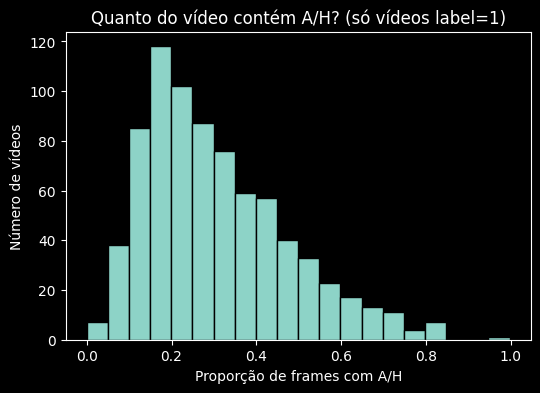

In [27]:
# Proporção de frames com A/H nos vídeos positivos
ah_frame_ratios = []

for vid, data in annotations.items():
    if data['global_ah'] == 1:
        frames = data.get('frame_annotation', [])
        if frames:
            total = len(frames)
            ah_count = sum(1 for f in frames if f[1] == 1)
            ah_frame_ratios.append(ah_count / total)

print(f"Nos vídeos com A/H:")
print(f"  Proporção média de frames A/H: {sum(ah_frame_ratios)/len(ah_frame_ratios)*100:.1f}%")
print(f"  Min: {min(ah_frame_ratios)*100:.1f}%")
print(f"  Max: {max(ah_frame_ratios)*100:.1f}%")

plt.figure(figsize=(6,4))
plt.hist(ah_frame_ratios, bins=20, edgecolor='black')
plt.xlabel("Proporção de frames com A/H")
plt.ylabel("Número de vídeos")
plt.title("Quanto do vídeo contém A/H? (só vídeos label=1)")
plt.show()

In [28]:
# Contar frequência de cada cue por categoria
from collections import Counter

cue_counts = {
    'audio': Counter(),
    'body': Counter(),
    'facial': Counter(),
    'inconsistencies': Counter(),
    'language': Counter()
}

for vid, data in annotations.items():
    cues = data.get('all_cues', [])
    for cue_set in cues:
        for category, value in cue_set.items():
            if value is not None:
                # Separar cues múltiplas (ex: "filler sound-hedging")
                # Contar tanto o valor completo quanto os sub-cues
                cue_counts[category][value] += 1

# Mostrar top cues por categoria
for category, counts in cue_counts.items():
    print(f"\n=== {category.upper()} (total: {sum(counts.values())}) ===")
    for cue, count in counts.most_common(15):
        print(f"  {cue}: {count}")


=== AUDIO (total: 440) ===
  pause: 60
  Slow: 53
  Pause: 53
  slow: 18
  Fast: 18
  Breath: 14
  Slow - Pause: 14
  breath: 13
  fast: 12
  Laugh: 10
  pause, slow: 9
  laugh: 8
  pause, slow, breath: 7
  pause-click: 7
  Pause - Slow: 6

=== BODY (total: 458) ===
  Shake: 30
  shake: 28
  Nod: 20
  Look away: 16
  Throw: 16
  throw: 15
  tilt: 14
  shrug: 14
  posture: 13
  look away: 12
  nod: 9
  Posture: 8
  Shrug: 8
  Sigh: 8
  sigh: 8

=== FACIAL (total: 550) ===
  Gaze: 28
  gaze: 17
  gaze-smile: 11
  Smile: 9
  gaze-eyebrow: 8
  Eyebrow: 6
  Smile - Gaze: 6
  Close 2 - Eyebrow: 6
  Gaze - Hanging: 6
  Gaze - Mouth: 6
  eyebrow: 5
  mouth: 5
  eyebrow-gaze: 5
  hanging: 4
  Smile - Gaze - Eyebrow: 4

=== INCONSISTENCIES (total: 215) ===
  FL: 46
  LB: 28
  FL - LB: 24
  FL-LB: 12
  FL - LA: 12
  FL-LA: 12
  LB - FL: 10
  FL - LA - LB: 7
  FB: 6
  LA: 5
  FL-FB: 5
  LA - FL: 3
  FL - FB: 3
  FB - LB: 3
  FB - FL: 3

=== LANGUAGE (total: 488) ===
  Filler sound: 33
  Positive:

In [29]:
# Cues aparecem só em vídeos com A/H?
cues_ah1 = 0
cues_ah0 = 0

for vid, data in annotations.items():
    cues = data.get('all_cues', [])
    tem_cue = any(
        any(v is not None for v in cue_set.values())
        for cue_set in cues
    )
    if tem_cue:
        if data['global_ah'] == 1:
            cues_ah1 += 1
        else:
            cues_ah0 += 1

print(f"Vídeos COM cues e label=1 (A/H): {cues_ah1}")
print(f"Vídeos COM cues e label=0 (sem A/H): {cues_ah0}")

Vídeos COM cues e label=1 (A/H): 333
Vídeos COM cues e label=0 (sem A/H): 0


# Análise dos transcritos

Frames por vídeo:
  Min: 73
  Max: 2295
  Média: 642
  Mediana: 544


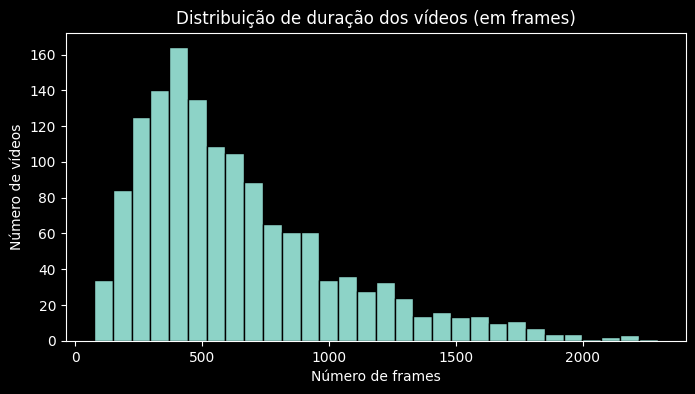

In [30]:
# Duração dos vídeos (via número de frames)
frame_counts = []
for vid, data in annotations.items():
    frames = data.get('frame_annotation', [])
    frame_counts.append(len(frames))

frame_counts = pd.Series(frame_counts)

# Assumindo ~24-30fps, converter pra segundos
print(f"Frames por vídeo:")
print(f"  Min: {frame_counts.min()}")
print(f"  Max: {frame_counts.max()}")
print(f"  Média: {frame_counts.mean():.0f}")
print(f"  Mediana: {frame_counts.median():.0f}")

plt.figure(figsize=(8,4))
plt.hist(frame_counts, bins=30, edgecolor='black')
plt.xlabel("Número de frames")
plt.ylabel("Número de vídeos")
plt.title("Distribuição de duração dos vídeos (em frames)")
plt.show()

Transcritos:
  Com texto: 1427
  Vazios: 0
  Palavras por transcrito:
    Min: 1
    Max: 278
    Média: 59
    Mediana: 48


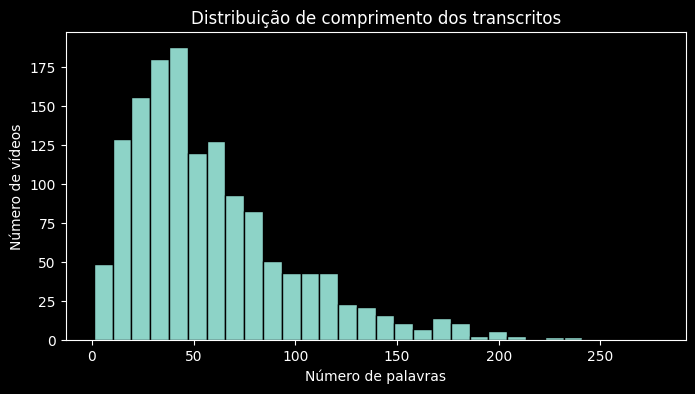

In [31]:
# Análise dos transcritos
transcript_lengths = []
empty_transcripts = 0

for vid, data in annotations.items():
    transcript = data.get('transcript', {})
    text = transcript.get('text', '') if isinstance(transcript, dict) else ''
    if text:
        transcript_lengths.append(len(text.split()))
    else:
        empty_transcripts += 1

transcript_lengths = pd.Series(transcript_lengths)

print(f"Transcritos:")
print(f"  Com texto: {len(transcript_lengths)}")
print(f"  Vazios: {empty_transcripts}")
print(f"  Palavras por transcrito:")
print(f"    Min: {transcript_lengths.min()}")
print(f"    Max: {transcript_lengths.max()}")
print(f"    Média: {transcript_lengths.mean():.0f}")
print(f"    Mediana: {transcript_lengths.median():.0f}")

plt.figure(figsize=(8,4))
plt.hist(transcript_lengths, bins=30, edgecolor='black')
plt.xlabel("Número de palavras")
plt.ylabel("Número de vídeos")
plt.title("Distribuição de comprimento dos transcritos")
plt.show()

In [32]:
from wordcloud import WordCloud
from collections import Counter
import re

# Separar transcritos por classe
texts_ah = []
texts_no_ah = []

for split_name in ['train', 'val', 'test']:
    filepath = os.path.join(split_dir, f'{split_name}.txt')
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f.readlines():
            parts = line.strip().split(',', 2)
            participant_id = parts[0].split('/')[1]
            if participant_id not in excluded_ids:
                label = int(parts[1])
                text = parts[2] if len(parts) > 2 else ''
                if label == 1:
                    texts_ah.append(text.lower())
                else:
                    texts_no_ah.append(text.lower())

all_texts = texts_ah + texts_no_ah
print(f"Vídeos A/H: {len(texts_ah)} | Sem A/H: {len(texts_no_ah)} | Total: {len(all_texts)}")

Vídeos A/H: 778 | Sem A/H: 649 | Total: 1427


In [33]:
# Stopwords comuns em inglês
stopwords = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you', 'your',
    'he', 'she', 'it', 'its', 'they', 'them', 'their', 'what', 'which',
    'who', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was',
    'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do',
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or',
    'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with',
    'about', 'against', 'between', 'through', 'during', 'before', 'after',
    'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on',
    'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'both', 'each',
    'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can',
    'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're',
    've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn',
    'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn',
    'wasn', 'weren', 'won', 'wouldn', 'also', 'really', 'like', 'would',
    'could', 'much', 'get', 'go', 'going', 'one', 'thing', 'things',
    'know', 'think', 'lot', 'make', 'even', 'well', 'something'])

def get_word_counts(texts, stopwords):
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]+\b', text)
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    return Counter(words)

counts_all = get_word_counts(all_texts, stopwords)
counts_ah = get_word_counts(texts_ah, stopwords)
counts_no_ah = get_word_counts(texts_no_ah, stopwords)

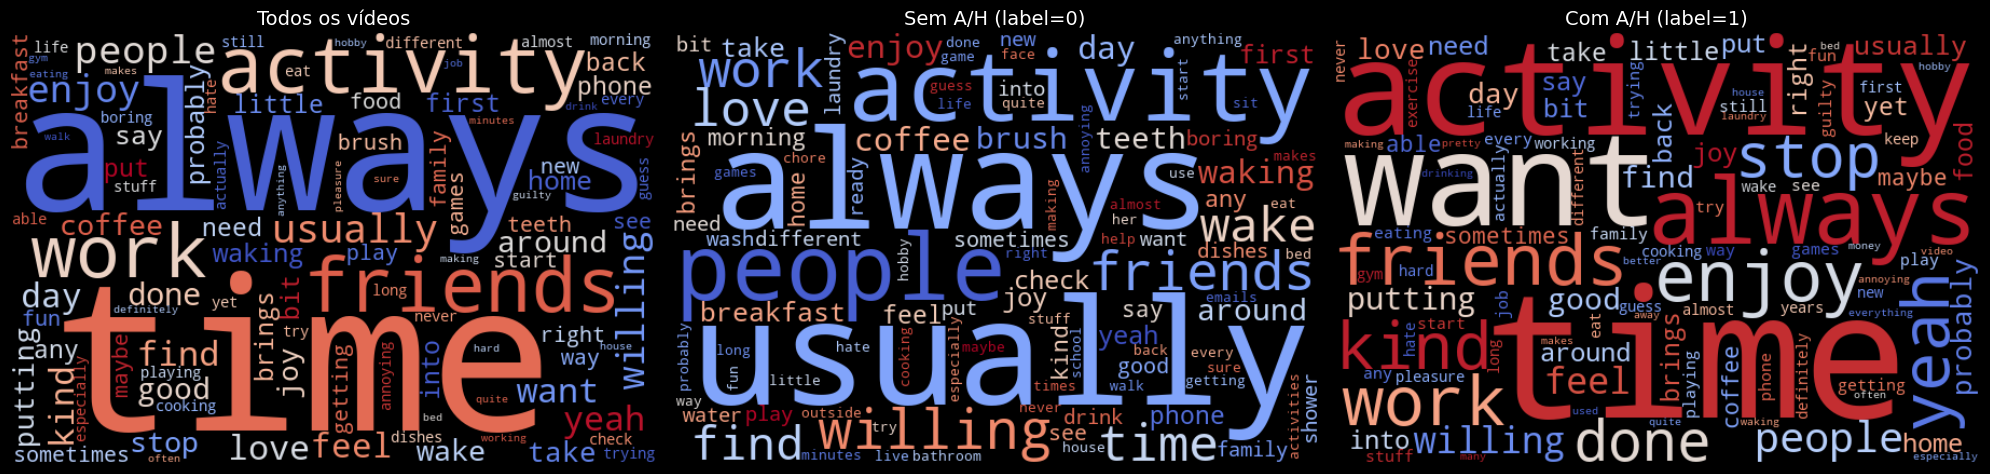

In [34]:
# Nuvens de palavras
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, counts, title in [
    (axes[0], counts_all, "Todos os vídeos"),
    (axes[1], counts_no_ah, "Sem A/H (label=0)"),
    (axes[2], counts_ah, "Com A/H (label=1)")
]:
    wc = WordCloud(width=600, height=400, background_color='black',
                   colormap='coolwarm', max_words=100).generate_from_frequencies(counts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [35]:
# Ranking top 20 lado a lado
print(f"{'Rank':<5} {'Sem A/H':<25} {'Com A/H':<25}")
print("-" * 55)

top_no_ah = counts_no_ah.most_common(20)
top_ah = counts_ah.most_common(20)

for i in range(20):
    w_no, c_no = top_no_ah[i]
    w_ah, c_ah = top_ah[i]
    print(f"{i+1:<5} {w_no:<15} ({c_no:<4})    {w_ah:<15} ({c_ah:<4})")

Rank  Sem A/H                   Com A/H                  
-------------------------------------------------------
1     usually         (203 )    time            (293 )
2     always          (176 )    activity        (194 )
3     activity        (144 )    want            (187 )
4     people          (142 )    always          (183 )
5     willing         (140 )    friends         (180 )
6     friends         (136 )    enjoy           (178 )
7     work            (132 )    work            (166 )
8     love            (122 )    yeah            (157 )
9     time            (120 )    kind            (150 )
10    wake            (112 )    stop            (145 )
11    find            (103 )    done            (142 )
12    waking          (97  )    people          (142 )
13    enjoy           (95  )    willing         (132 )
14    coffee          (92  )    feel            (131 )
15    day             (91  )    putting         (128 )
16    teeth           (79  )    good            (117 )
17    

In [36]:
# Palavras mais discriminativas: diferença de frequência relativa
total_ah = sum(counts_ah.values())
total_no_ah = sum(counts_no_ah.values())

all_words = set(counts_ah.keys()) | set(counts_no_ah.keys())

diffs = {}
for word in all_words:
    freq_ah = counts_ah.get(word, 0) / total_ah
    freq_no_ah = counts_no_ah.get(word, 0) / total_no_ah
    diffs[word] = freq_ah - freq_no_ah

# Top palavras mais associadas a A/H
print("=== Palavras mais associadas a A/H ===")
for word, diff in sorted(diffs.items(), key=lambda x: -x[1])[:15]:
    print(f"  {word:<20} (A/H: {counts_ah.get(word,0)}, Sem: {counts_no_ah.get(word,0)}, diff: {diff:.4f})")

print("\n=== Palavras mais associadas a NÃO A/H ===")
for word, diff in sorted(diffs.items(), key=lambda x: x[1])[:15]:
    print(f"  {word:<20} (A/H: {counts_ah.get(word,0)}, Sem: {counts_no_ah.get(word,0)}, diff: {diff:.4f})")

=== Palavras mais associadas a A/H ===
  stop                 (A/H: 145, Sem: 8, diff: 0.0073)
  want                 (A/H: 187, Sem: 41, diff: 0.0069)
  time                 (A/H: 293, Sem: 120, diff: 0.0061)
  putting              (A/H: 128, Sem: 15, diff: 0.0058)
  done                 (A/H: 142, Sem: 28, diff: 0.0055)
  kind                 (A/H: 150, Sem: 51, diff: 0.0040)
  probably             (A/H: 100, Sem: 30, diff: 0.0030)
  yet                  (A/H: 65, Sem: 10, diff: 0.0027)
  yeah                 (A/H: 157, Sem: 72, diff: 0.0026)
  good                 (A/H: 117, Sem: 47, diff: 0.0025)
  guilty               (A/H: 53, Sem: 5, diff: 0.0025)
  food                 (A/H: 68, Sem: 19, diff: 0.0022)
  pleasure             (A/H: 50, Sem: 8, diff: 0.0021)
  eating               (A/H: 50, Sem: 8, diff: 0.0021)
  job                  (A/H: 51, Sem: 10, diff: 0.0020)

=== Palavras mais associadas a NÃO A/H ===
  usually              (A/H: 89, Sem: 203, diff: -0.0121)
  wake       